# **Laboratorio Aprendizaje Automático**
## Sesión Práctica 3 - Conjunto de datos, Sesgo/Varianza
2026-1

In [ ]:
#Importar datos
import kagglehub

path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")
print("Path to dataset files:", path)

100%|██████████| 25.6k/25.6k [00:00<00:00, 10.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uciml/red-wine-quality-cortez-et-al-2009/versions/2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## 1. Exploración y visualización del conjunto de datos


In [ ]:
csv_path = path +'/winequality-red.csv'

wine_df = pd.read_csv(csv_path, sep=',', on_bad_lines='skip')
display(wine_df.head())
display(wine_df.info())
display(wine_df.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


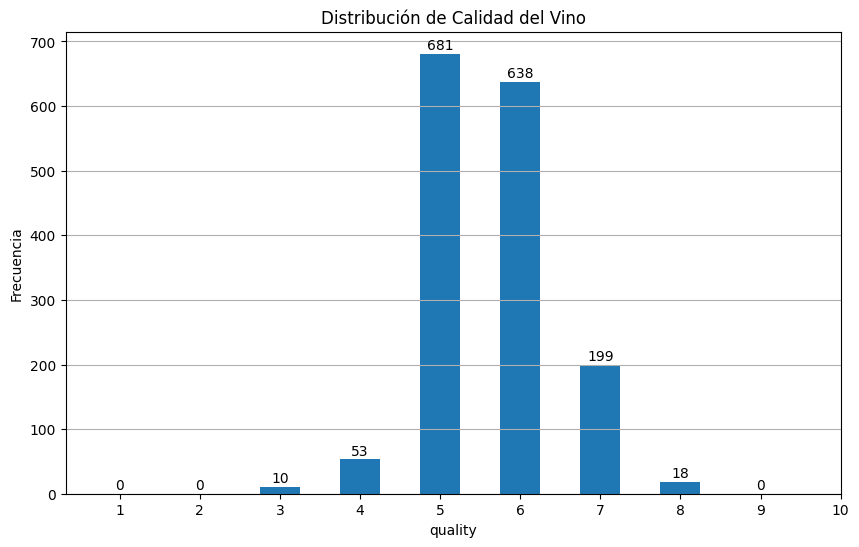

In [ ]:
plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(wine_df['quality'],
                                 bins=range(1, 11), align='left', rwidth=0.5)
# Bins [1, 2), [2, 3), [3,4), etc.

for count, bin, patch in zip(counts, bins, patches):
    height = patch.get_height()
    plt.annotate(f'{int(count)}', xy=(bin, height), xytext=(0, 1),
                 textcoords='offset points', ha='center', va='bottom')

plt.title('Distribución de Calidad del Vino')
plt.xlabel(wine_df.columns[-1])
plt.ylabel('Frecuencia')
plt.xticks(range(1, 11))
plt.grid(axis='y')
plt.show()

## 2. División del conjuntos de datos para aprendizaje

<div>
<center>
<img src="https://drive.google.com/uc?export=view&id=1kZ5eANMMIC5-5OXThAWPoi2_hgKjyP4Z" width="800"/>
</center>
</div>

*¿Qué sería un problema al momento de muestrear aleatoriamente sobre mi conjunto de datos original con tal de generar 3 nuevos conjuntos?* <br>
Bueno, podrían existir varios. Uno común es la **pérdida de la distribución de datos de mi conjunto original** (gran impacto en mi aprendizaje y evaluación del mismo).

In [ ]:
# 70% train, 30% test
train_ds, test_ds = train_test_split(
    wine_df,    # Le entrego el dataset completo
    stratify = wine_df['quality'],  # Parámetro mágico. Especifico qué distribución conservar.
    test_size = 0.3,
    random_state=42)

# 75% train, 25% validation
train_ds, val_ds = train_test_split(
    train_ds,   # Le entrego el conjunto entrenamiento
    stratify = train_ds['quality'],
    test_size = 0.25,
    random_state=42)

# Verificar proporciones
display('Proporción original', wine_df['quality'].value_counts() / len(wine_df))
display('Proporción entrenamiento', train_ds['quality'].value_counts() / len(train_ds))
display('Proporción validación', val_ds['quality'].value_counts() / len(val_ds))
display('Proporción prueba', test_ds['quality'].value_counts() / len(test_ds))

'Proporción original'

,count
quality,
5,0.425891
6,0.398999
7,0.124453
4,0.033146
8,0.011257
3,0.006254


'Proporción entrenamiento'

,count
quality,
5,0.426698
6,0.398093
7,0.123957
4,0.033373
8,0.011919
3,0.005959


'Proporción validación'

,count
quality,
5,0.425000
6,0.400000
7,0.125000
4,0.032143
8,0.010714
3,0.007143


'Proporción prueba'

,count
quality,
5,0.425000
6,0.400000
7,0.125000
4,0.033333
8,0.010417
3,0.006250


**OJO!** En el bloque anterior utilizamos el método train_test_split() para separar cada uno de nuestros conjuntos. El orden en el que se realizaron y **el conjunto de origen utilizado** para generar cada uno es muy importante.<br>
Recordemos el diagrama inicial: La división del **conjunto completo** separa mis conjuntos de entrenamiento y de prueba (70/30). **Luego** se toma y divide el **conjunto de prueba** en un nuevo conjunto de prueba final y conjunto validación (75/25).<br><br>
- Un 30% de los **datos** será utilizado para probar mi modelo.
- Un 75% del 70% de los **datos de entrenamiento** será utilizado para entrenar mi modelo: es decir, un 52.5~% de los datos se usarán para **entrenar**.
- Un 25% del 70% de los **datos de entrenamiento** será utilizado para validar mi modelo: es decir, un 17.5~% de los datos se usarán para **validar**.

Esto me produce un *split* muy extraño de **52.5/17.5/30**.<br>
Solo falta obtener las etiquetas para cada *split*.

In [ ]:
def divide_partition_set(df, target_column):
  y = df[target_column].copy()
  X = df.drop(target_column, axis=1)
  return X, y


train_x, train_y = divide_partition_set(train_ds, 'quality')
val_x, val_y = divide_partition_set(val_ds, 'quality')
test_x, test_y = divide_partition_set(test_ds, 'quality')

display(train_x.info())
display(val_x.info())
display(test_x.info())

<class 'pandas.core.frame.DataFrame'>
Index: 839 entries, 597 to 1515
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         839 non-null    float64
 1   volatile acidity      839 non-null    float64
 2   citric acid           839 non-null    float64
 3   residual sugar        839 non-null    float64
 4   chlorides             839 non-null    float64
 5   free sulfur dioxide   839 non-null    float64
 6   total sulfur dioxide  839 non-null    float64
 7   density               839 non-null    float64
 8   pH                    839 non-null    float64
 9   sulphates             839 non-null    float64
 10  alcohol               839 non-null    float64
dtypes: float64(11)
memory usage: 78.7 KB


None

<class 'pandas.core.frame.DataFrame'>
Index: 280 entries, 1338 to 1276
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         280 non-null    float64
 1   volatile acidity      280 non-null    float64
 2   citric acid           280 non-null    float64
 3   residual sugar        280 non-null    float64
 4   chlorides             280 non-null    float64
 5   free sulfur dioxide   280 non-null    float64
 6   total sulfur dioxide  280 non-null    float64
 7   density               280 non-null    float64
 8   pH                    280 non-null    float64
 9   sulphates             280 non-null    float64
 10  alcohol               280 non-null    float64
dtypes: float64(11)
memory usage: 26.2 KB


None

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 416 to 1049
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         480 non-null    float64
 1   volatile acidity      480 non-null    float64
 2   citric acid           480 non-null    float64
 3   residual sugar        480 non-null    float64
 4   chlorides             480 non-null    float64
 5   free sulfur dioxide   480 non-null    float64
 6   total sulfur dioxide  480 non-null    float64
 7   density               480 non-null    float64
 8   pH                    480 non-null    float64
 9   sulphates             480 non-null    float64
 10  alcohol               480 non-null    float64
dtypes: float64(11)
memory usage: 45.0 KB


None

## 3. Validación cruzada k-fold

<div>
<center>
<img src="https://drive.google.com/uc?export=view&id=1unQrADileIiG3L5a80oUfdMhlmB_js90" width="600"/>
</center>
</div>

*¿Qué beneficios introduce esta técnica?*
<br>
<br>
Recordemos que un modelo corresponde a un **problema de optimización** con una función objetivo que (por lo general) busca ser minimizada. De esta forma, el espacio de búsqueda y forma de la función objetivo a optimizar son **dictados por los datos**. Distintos datos resultan en una función y espacio de búsqueda distintos; por lo tanto, un **problema distinto**.

In [ ]:
# 80% train, 20% test
train_ds, test_ds = train_test_split(
    wine_df,
    stratify = wine_df['quality'],
    test_size = 0.2,
    random_state=42)

train_x, train_y = divide_partition_set(train_ds, 'quality')
test_x, test_y = divide_partition_set(test_ds, 'quality')

# Escalamiento de características y definición de modelo
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=100))
])

# 5-folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluar
scores = cross_val_score(pipeline, train_x, train_y, scoring='accuracy', cv=kfold)

print("Scores por fold:", scores)
print("Accuracy promedio:", np.mean(scores))

Scores por fold: [0.61328125 0.5625     0.5625     0.61328125 0.61960784]
Accuracy promedio: 0.594234068627451


# **BIAS**
Entiéndase como una tendencia, inclinación o **sesgo** presente en los resultados de mi modelo. Qué tanto se alejan mis resultados del valor esperado real.<br> Este puede provenir de distintas fuentes. Puedo estar experimentando bias ...

* __... de datos__: los datos con los que entreno mi modelo impiden que el modelo aprenda a identificar todos los casos deseados.
* __... de modelo__: el modelo que escogí para aprender no es suficiente/apropiado para representar la complejidad subyacente en mis datos.
* __... cognitivo__: ya sea en la toma misma de datos o en las distintas etapas del proceso de aprendizaje, se introducen sesgos **propios del ser humano**.

## **¿Qué problemas surgen de aquí, cómo diagnosticarlos y qué hacer?**

* Subajuste (_underfitting_): El modelo **no está aprendiendo** y produce resultados con un alto grado de error. <br>Se aprecia un alto % de error en el entrenamiento **y también** en la evaluación.<br> **Solución**:
    * Pre-procesamiento y preparación del conjunto de datos.
    * Post-procesamiento e interpretación de predicciones.
    * Cambiar modelo acorde a complejidad de mis datos.

# **VARIANCE**
__Volvamos a estadística...__ donde entendemos la varianza como una medición de cuánto difieren nuestros valores de una __promedio/aproximación/generalización__.<br>En aprendizaje, se observa el fenómeno al momento de evaluar un modelo con su conjunto de prueba o al compararlo a otra iteración utilizando un conjunto de datos distinto. Se refiere a una diferencia dispersa entre las predicciones y el valor real esperado.

## **¿Qué problemas surgen de aquí, cómo diagnosticarlos y qué hacer?**

* Sobreajuste (_overfitting_): El modelo **está "memorizando"** los datos de aprendizaje, de tal forma que frente a nuevos datos, este falla. <br>Se aprecia un bajo % de error en el entrenamiento **y un alto % de error** en la evaluación.<br> **Solución**:
    * Validación cruzada.
    * Eliminación de características que no inciden sobre la variable objetivo.
    * Simplificación del modelo acorde a complejidad subyacente de los datos.
    * ¡Más datos!
<div>
<center>
<img src="https://drive.google.com/uc?export=view&id=18W9RyTxICDvEgsy-oGhMRC6baTiYyaHy" width="600"/>
</center>
</div>